# Prediksi Risiko Kesehatan Berdasarkan Pola Gaya Hidup Modern Menggunakan Machine Learning

**Dataset:** `sleep_mobile_stress_dataset_15000.csv`  
**Target:** Klasifikasi 3 kelas — Risiko Rendah, Risiko Sedang, Risiko Tinggi

**Pipeline model:**
1. Kandidat model utama (web): **Logistic Regression**, **Random Forest**, **XGBoost**, **SVM**
2. Hyperparameter tuning menggunakan **RandomizedSearchCV (cv=5)**
3. Model terbaik dipilih secara otomatis dan disimpan dalam format `.joblib` untuk deployment web.

**Kriteria pemilihan model final:**
- **Recall kelas Risiko Tinggi** sebagai prioritas utama
- Diikuti F1-Score, Precision, dan Accuracy

---

> Notebook ini disusun secara bertahap dan dilengkapi penjelasan di setiap tahapan untuk keperluan laporan penulisan ilmiah.

---
## Tahap 1 — Import Library

Pada tahap ini, seluruh library yang diperlukan diimport terlebih dahulu. Library yang digunakan meliputi:
- **pandas & numpy**: manipulasi dan komputasi data
- **matplotlib & seaborn**: visualisasi data
- **scikit-learn**: preprocessing, evaluasi, dan model klasifikasi (Logistic Regression, Random Forest, SVM)
- **xgboost**: model klasifikasi gradient boosting (XGBoost)
- **joblib & json**: menyimpan model dan konfigurasi preprocessing

In [2]:
# ─── Import Library ───────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import joblib
import os
import warnings
import time
warnings.filterwarnings('ignore')

# Scikit-learn
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, make_scorer)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.inspection import permutation_importance
from sklearn.preprocessing import label_binarize

# XGBoost
from xgboost import XGBClassifier

# Imbalanced-learn
from imblearn.pipeline import Pipeline as ImbPipeline

# Scipy (untuk distribusi hyperparameter)
from scipy.stats import uniform, randint, loguniform

print("Semua library berhasil diimport.")

Semua library berhasil diimport.


---
## Tahap 2 — Load Dataset

Dataset dimuat menggunakan `pandas.read_csv()`. Selanjutnya dilakukan eksplorasi awal untuk memahami struktur data, meliputi jumlah baris dan kolom, nama kolom, tipe data, statistik deskriptif, serta pengecekan nilai kosong dan duplikasi.

In [3]:
# ─── Load Dataset ─────────────────────────────────────────────────────────────
# Sesuaikan path file dataset jika diperlukan
df = pd.read_csv('sleep_mobile_stress_dataset_15000.csv')

print("=" * 55)
print("INFORMASI AWAL DATASET")
print("=" * 55)
print(f"Jumlah baris    : {df.shape[0]:,}")
print(f"Jumlah kolom    : {df.shape[1]}")
print(f"Nama kolom      : {list(df.columns)}")

print("\n5 Data Teratas:")
display(df.head())

print("\nTipe Data Setiap Kolom:")
display(df.dtypes.to_frame(name='Tipe Data'))

print("\nStatistik Deskriptif:")
display(df.describe())

print("\nJumlah Missing Values per Kolom:")
display(df.isnull().sum().to_frame(name='Missing Values'))

print(f"\nJumlah Data Duplikat: {df.duplicated().sum()}")

INFORMASI AWAL DATASET
Jumlah baris    : 15,000
Jumlah kolom    : 13
Nama kolom      : ['user_id', 'age', 'gender', 'occupation', 'daily_screen_time_hours', 'phone_usage_before_sleep_minutes', 'sleep_duration_hours', 'sleep_quality_score', 'stress_level', 'caffeine_intake_cups', 'physical_activity_minutes', 'notifications_received_per_day', 'mental_fatigue_score']

5 Data Teratas:


,user_id,age,gender,occupation,daily_screen_time_hours,phone_usage_before_sleep_minutes,sleep_duration_hours,sleep_quality_score,stress_level,caffeine_intake_cups,physical_activity_minutes,notifications_received_per_day,mental_fatigue_score
0,1,56,Female,Designer,3.26,86,5.31,7.72,3.49,0,35,119,3.57
1,2,46,Female,Teacher,1.85,32,7.36,9.70,3.01,0,16,299,1.91
2,3,32,Female,Designer,3.04,107,4.50,6.38,5.03,0,17,21,6.05
3,4,25,Male,Software Engineer,9.00,36,6.68,5.53,10.00,0,3,220,9.92
4,5,38,Female,Teacher,3.52,56,7.57,6.69,6.71,4,92,167,5.99



Tipe Data Setiap Kolom:


,Tipe Data
user_id,int64
age,int64
gender,object
occupation,object
daily_screen_time_hours,float64
phone_usage_before_sleep_minutes,int64
sleep_duration_hours,float64
sleep_quality_score,float64
stress_level,float64
caffeine_intake_cups,int64



Statistik Deskriptif:


,user_id,age,daily_screen_time_hours,phone_usage_before_sleep_minutes,sleep_duration_hours,sleep_quality_score,stress_level,caffeine_intake_cups,physical_activity_minutes,notifications_received_per_day,mental_fatigue_score
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.00000,15000.000000,15000.000000,15000.000000
mean,7500.500000,38.488467,5.501528,59.708933,6.509683,6.246362,6.980247,1.99880,59.157133,160.890467,6.873009
std,4330.271354,12.007970,2.600085,34.641858,1.452689,1.713644,2.749382,1.41459,34.525705,80.856902,2.730482
min,1.000000,18.000000,1.000000,0.000000,4.000000,1.000000,1.000000,0.00000,0.000000,20.000000,1.000000
25%,3750.750000,28.000000,3.260000,29.000000,5.260000,5.000000,4.750000,1.00000,29.000000,92.000000,4.700000
50%,7500.500000,38.000000,5.490000,60.000000,6.490000,6.250000,7.380000,2.00000,59.000000,162.000000,7.380000
75%,11250.250000,49.000000,7.760000,90.000000,7.790000,7.500000,10.000000,3.00000,89.000000,231.000000,9.450000
max,15000.000000,59.000000,10.000000,119.000000,9.000000,10.000000,10.000000,4.00000,119.000000,299.000000,10.000000



Jumlah Missing Values per Kolom:


,Missing Values
user_id,0
age,0
gender,0
occupation,0
daily_screen_time_hours,0
phone_usage_before_sleep_minutes,0
sleep_duration_hours,0
sleep_quality_score,0
stress_level,0
caffeine_intake_cups,0



Jumlah Data Duplikat: 0


---
## Tahap 3 — Data Understanding

Pada tahap ini, setiap fitur utama yang akan digunakan dalam model dijelaskan secara singkat beserta relevansinya terhadap prediksi risiko kesehatan.

| Fitur | Deskripsi | Relevansi |
|---|---|---|
| `daily_screen_time_hours` | Total waktu penggunaan layar per hari (jam) | Penggunaan layar berlebihan berkaitan dengan gangguan tidur dan stres |
| `phone_usage_before_sleep_minutes` | Durasi penggunaan HP sebelum tidur (menit) | Cahaya biru dari layar mengganggu produksi melatonin sehingga menurunkan kualitas tidur |
| `sleep_duration_hours` | Durasi tidur per hari (jam) | Tidur yang cukup merupakan indikator utama kesehatan fisik dan mental |
| `sleep_quality_score` | Skor kualitas tidur (skala tertentu) | Kualitas tidur yang buruk meningkatkan risiko berbagai penyakit kronis |
| `physical_activity_minutes` | Total aktivitas fisik per hari (menit) | Aktivitas fisik yang cukup menurunkan risiko penyakit kardiovaskular dan metabolik |
| `notifications_received_per_day` | Jumlah notifikasi diterima per hari | Gangguan notifikasi yang tinggi berkaitan dengan peningkatan stres dan gangguan fokus |
| `stress_level` | Tingkat stres (skala tertentu) | Stres kronis merupakan faktor risiko utama berbagai gangguan kesehatan |
| `mental_fatigue_score` | Skor kelelahan mental (skala tertentu) | Kelelahan mental yang tinggi menurunkan imunitas dan produktivitas |

In [4]:
# ─── Analisis Kolom Tambahan ───────────────────────────────────────────────────
# Identifikasi kolom yang ada di dataset
CORE_FEATURES = [
    'daily_screen_time_hours',
    'phone_usage_before_sleep_minutes',
    'sleep_duration_hours',
    'sleep_quality_score',
    'physical_activity_minutes',
    'notifications_received_per_day',
    'stress_level',
    'mental_fatigue_score'
]

# Kolom tambahan di luar fitur utama
extra_cols = [c for c in df.columns if c not in CORE_FEATURES]
print("Kolom di luar fitur utama:", extra_cols)

# Analisis singkat kolom tambahan
for col in extra_cols:
    print(f"\n--- {col} ---")
    if df[col].dtype == 'object':
        print(df[col].value_counts())
    else:
        print(df[col].describe())

Kolom di luar fitur utama: ['user_id', 'age', 'gender', 'occupation', 'caffeine_intake_cups']

--- user_id ---
count    15000.000000
mean      7500.500000
std       4330.271354
min          1.000000
25%       3750.750000
50%       7500.500000
75%      11250.250000
max      15000.000000
Name: user_id, dtype: float64

--- age ---
count    15000.000000
mean        38.488467
std         12.007970
min         18.000000
25%         28.000000
50%         38.000000
75%         49.000000
max         59.000000
Name: age, dtype: float64

--- gender ---
gender
Male      7234
Female    7181
Other      585
Name: count, dtype: int64

--- occupation ---
occupation
Manager              1962
Doctor               1922
Software Engineer    1917
Freelancer           1891
Student              1861
Researcher           1837
Designer             1813
Teacher              1797
Name: count, dtype: int64

--- caffeine_intake_cups ---
count    15000.00000
mean         1.99880
std          1.41459
min          0.0

**Keputusan Penggunaan Kolom Tambahan:**

- **`age`**: Usia dapat memengaruhi toleransi stres dan kebutuhan tidur. Kolom ini **dipertimbangkan untuk digunakan** jika tersedia dan memiliki variasi yang cukup.
- **`gender`**: Gender dapat memengaruhi pola tidur dan respons stres. Jika digunakan, akan di-encode dengan `LabelEncoder`.
- **`occupation`**: Pekerjaan berkaitan dengan paparan stres dan gaya hidup digital. Namun, karena kategorinya banyak dan fokus penelitian adalah perilaku (bukan demografis pekerjaan), kolom ini **tidak digunakan** agar model tetap generalizable.

> Kolom `age` dan `gender` akan diikutsertakan dalam analisis korelasi untuk memutuskan secara data-driven apakah relevan.

---
## Tahap 4 — Pembersihan Data

Pembersihan data (data cleaning) dilakukan untuk memastikan kualitas data sebelum masuk ke tahap pemodelan. Tahap ini meliputi penanganan nilai kosong, data duplikat, outlier, dan validasi tipe data.

Missing values per kolom:
Tidak ditemukan missing values.

Jumlah duplikasi: 0
Baris setelah pembersihan duplikasi: 15,000

Deteksi Outlier (IQR):
  daily_screen_time_hours: 0 outlier (batas [-3.49, 14.51])
  phone_usage_before_sleep_minutes: 0 outlier (batas [-62.50, 181.50])
  sleep_duration_hours: 0 outlier (batas [1.46, 11.59])
  sleep_quality_score: 9 outlier (batas [1.25, 11.25])
  physical_activity_minutes: 0 outlier (batas [-61.00, 179.00])
  notifications_received_per_day: 0 outlier (batas [-116.50, 439.50])
  stress_level: 0 outlier (batas [-3.12, 17.88])
  mental_fatigue_score: 0 outlier (batas [-2.42, 16.57])


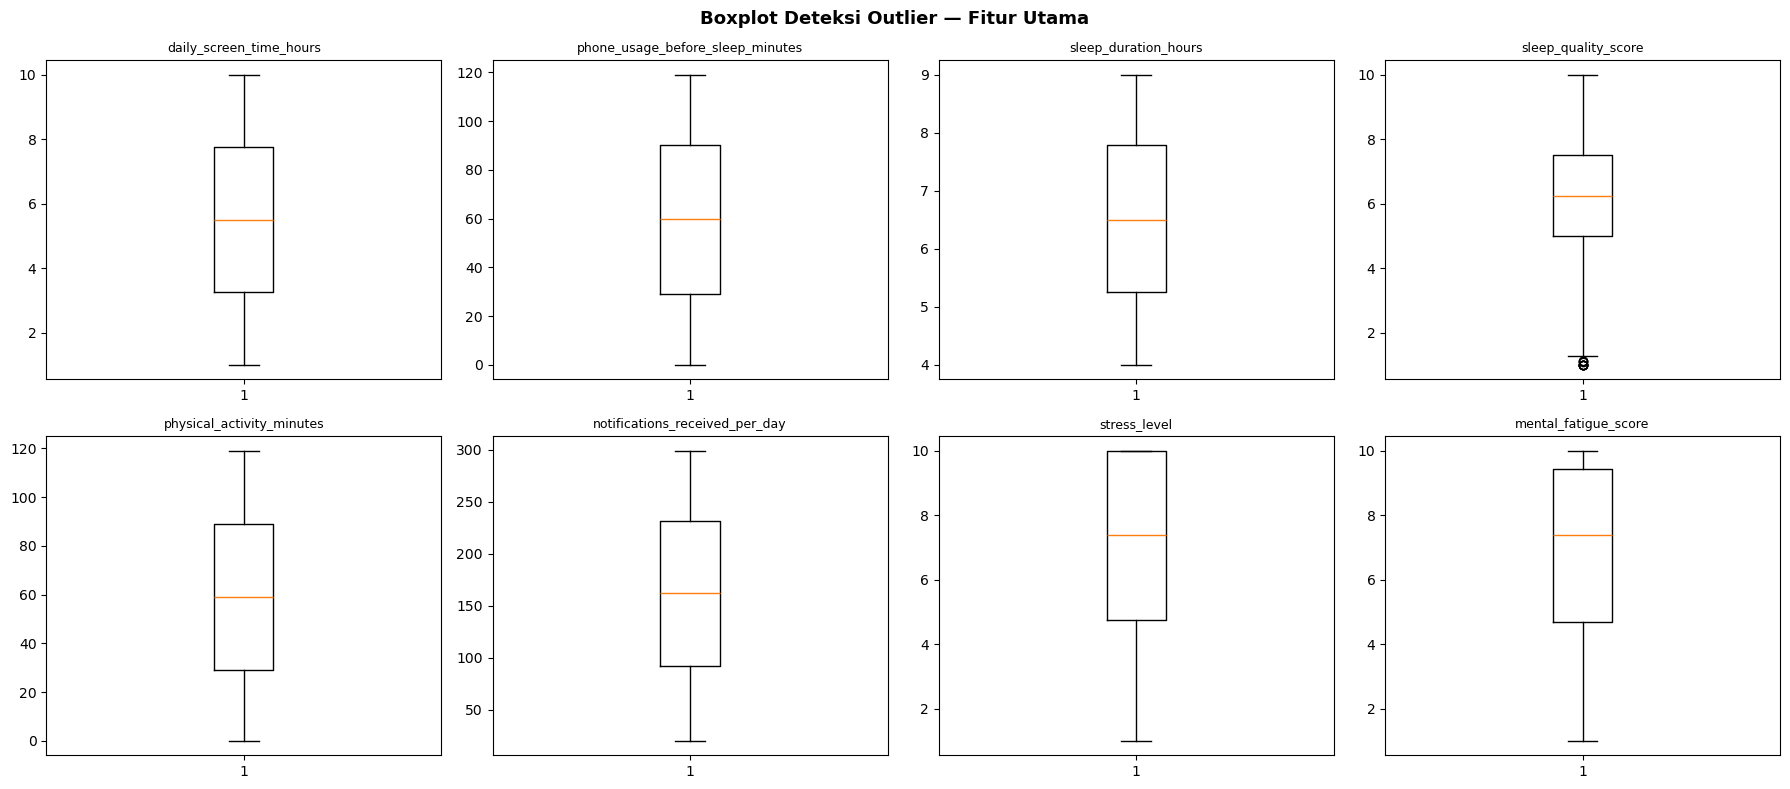


Oulier pada fitur utama umumnya merepresentasikan variasi nyata dalam gaya hidup,
sehingga TIDAK dihapus agar model dapat mempelajari pola ekstrem tersebut.

Dataset bersih: 15,000 baris × 13 kolom


In [5]:
# ─── Pembersihan Data ─────────────────────────────────────────────────────────

# 1. Salin dataset agar data asli tidak termodifikasi
df_clean = df.copy()

# 2. Tangani Missing Values
missing = df_clean.isnull().sum()
print("Missing values per kolom:")
print(missing[missing > 0] if missing.sum() > 0 else "Tidak ditemukan missing values.")

# Isi missing values numerik dengan median, kategorik dengan modus
for col in df_clean.columns:
    if df_clean[col].isnull().sum() > 0:
        if df_clean[col].dtype == 'object':
            df_clean[col].fillna(df_clean[col].mode()[0], inplace=True)
            print(f"  [{col}] diisi dengan modus: {df_clean[col].mode()[0]}")
        else:
            df_clean[col].fillna(df_clean[col].median(), inplace=True)
            print(f"  [{col}] diisi dengan median: {df_clean[col].median():.2f}")

# 3. Hapus duplikasi
n_dup = df_clean.duplicated().sum()
print(f"\nJumlah duplikasi: {n_dup}")
df_clean.drop_duplicates(inplace=True)
print(f"Baris setelah pembersihan duplikasi: {len(df_clean):,}")

# 4. Deteksi Outlier menggunakan IQR pada fitur utama numerik
print("\nDeteksi Outlier (IQR):")
outlier_info = {}
for col in CORE_FEATURES:
    if col in df_clean.columns and df_clean[col].dtype != 'object':
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        n_out = df_clean[(df_clean[col] < lower) | (df_clean[col] > upper)].shape[0]
        outlier_info[col] = n_out
        print(f"  {col}: {n_out} outlier (batas [{lower:.2f}, {upper:.2f}])")

# Visualisasi Boxplot
available_core = [c for c in CORE_FEATURES if c in df_clean.columns]
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
for i, col in enumerate(available_core):
    axes[i].boxplot(df_clean[col].dropna())
    axes[i].set_title(col, fontsize=9)
    axes[i].set_xlabel('')
plt.suptitle('Boxplot Deteksi Outlier — Fitur Utama', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nOulier pada fitur utama umumnya merepresentasikan variasi nyata dalam gaya hidup,")
print("sehingga TIDAK dihapus agar model dapat mempelajari pola ekstrem tersebut.")

print(f"\nDataset bersih: {df_clean.shape[0]:,} baris × {df_clean.shape[1]} kolom")

---
## Tahap 5 — Pembentukan Label Risiko

### Logika Pembentukan `risk_score`

Karena dataset tidak memiliki label risiko kesehatan secara langsung, label dibentuk menggunakan **domain knowledge** berbasis literatur kesehatan digital. `risk_score` dihitung dalam rentang 0–100 menggunakan pendekatan **weighted scoring**.

**Formula:**

$$\text{risk\_score} = w_1 \cdot S_{screen} + w_2 \cdot S_{phone} + w_3 \cdot S_{sleep\_dur} + w_4 \cdot S_{sleep\_qual} + w_5 \cdot S_{activity} + w_6 \cdot S_{notif} + w_7 \cdot S_{stress} + w_8 \cdot S_{fatigue}$$

Di mana setiap komponen $S_x$ adalah nilai yang dinormalisasi (0–1) berdasarkan batas acuan kesehatan, dan $w_x$ adalah bobot kepentingan. Komponen dengan kondisi buruk menghasilkan nilai mendekati 1.

**Batas Acuan Kesehatan:**

| Fitur | Kondisi Baik | Kondisi Buruk |
|---|---|---|
| Screen time | < 4 jam/hari | ≥ 10 jam/hari |
| HP sebelum tidur | < 15 menit | ≥ 90 menit |
| Durasi tidur | 7–9 jam | < 5 jam atau > 10 jam |
| Kualitas tidur | skor tinggi = baik | skor rendah = buruk |
| Aktivitas fisik | ≥ 150 menit | < 20 menit |
| Notifikasi | < 50/hari | ≥ 200/hari |
| Stres | skor rendah = baik | skor tinggi = buruk |
| Mental fatigue | skor rendah = baik | skor tinggi = buruk |


Distribusi risk_score:
count    15000.000000
mean        47.630863
std         13.695248
min          7.840000
25%         37.557500
50%         48.045000
75%         57.842500
max         87.610000
Name: risk_score, dtype: float64

Distribusi risk_level:
risk_level
Risiko Sedang    5652
Risiko Tinggi    4798
Risiko Rendah    4550
Name: count, dtype: int64

Proporsi (%):
risk_level
Risiko Sedang    37.68 %
Risiko Tinggi    31.99 %
Risiko Rendah    30.33 %
Name: count, dtype: object


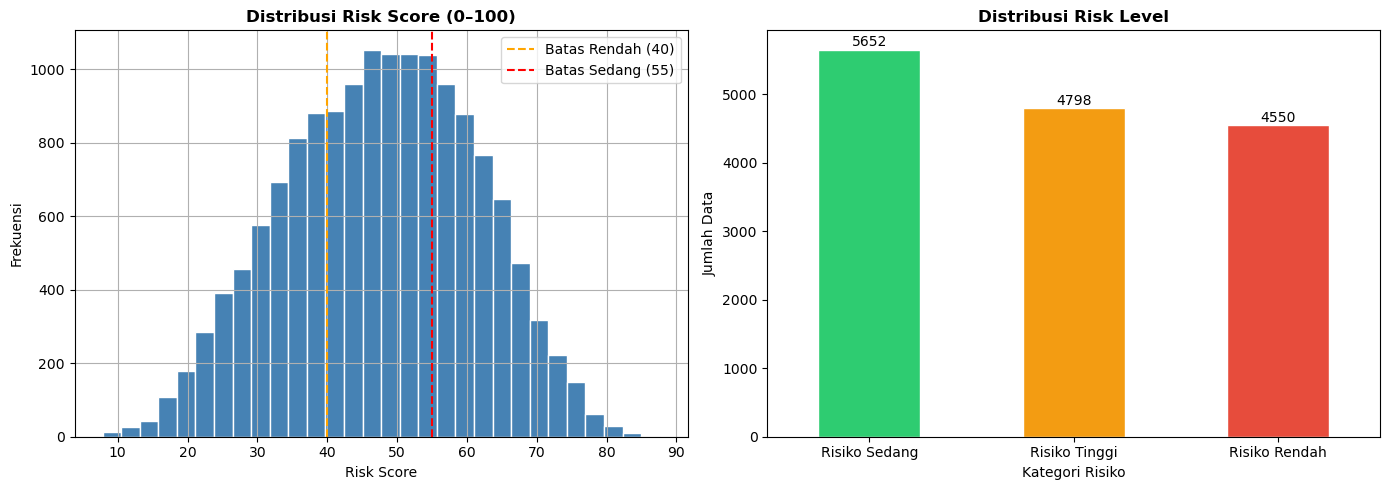

In [6]:
# ─── Pembentukan Label Risiko ──────────────────────────────────────────────────

def normalize_clip(val, low, high, invert=False):
    """Normalisasi nilai ke rentang [0,1] menggunakan batas low-high.
    invert=True jika nilai tinggi = kondisi BAIK (akan dibalik agar tinggi = risiko tinggi)."""
    norm = (val - low) / (high - low + 1e-9)
    norm = np.clip(norm, 0, 1)
    if invert:
        norm = 1 - norm
    return norm

def compute_risk_score(row):
    score = 0.0

    # 1. Screen time (0.08)
    s_screen = normalize_clip(row.get('daily_screen_time_hours', 4), low=4, high=10)
    score += 0.08 * s_screen

    # 2. Phone before sleep (0.08)
    s_phone = normalize_clip(row.get('phone_usage_before_sleep_minutes', 15), low=15, high=90)
    score += 0.08 * s_phone

    # 3. Sleep duration (0.15)
    sleep_dur = row.get('sleep_duration_hours', 7)
    if sleep_dur < 7:
        s_sleep = np.clip(1 - (sleep_dur - 4) / (7 - 4 + 1e-9), 0, 1)
    elif sleep_dur > 9:
        s_sleep = normalize_clip(sleep_dur, low=9, high=11)
    else:
        s_sleep = 0.0
    score += 0.15 * s_sleep

    # 4. Sleep quality (0.15)
    s_squal = normalize_clip(row.get('sleep_quality_score', 7), low=1, high=10, invert=True)
    score += 0.15 * s_squal

    # 5. Physical activity (0.15) -> batas atas 150 menit
    s_activity = normalize_clip(row.get('physical_activity_minutes', 30), low=0, high=150, invert=True)
    score += 0.15 * s_activity

    # 6. Notifications (0.08)
    s_notif = normalize_clip(row.get('notifications_received_per_day', 50), low=50, high=200)
    score += 0.08 * s_notif

    # 7. Stress level (0.12)
    s_stress = normalize_clip(row.get('stress_level', 5), low=1, high=10)
    score += 0.12 * s_stress

    # 8. Mental fatigue (0.08)
    s_fatigue = normalize_clip(row.get('mental_fatigue_score', 5), low=1, high=10)
    score += 0.08 * s_fatigue

    # 9. Caffeine intake (0.06)
    s_caffeine = normalize_clip(row.get('caffeine_intake_cups', 0), low=0, high=5)
    score += 0.06 * s_caffeine

    return round(score * 100, 2)

# ─── Terapkan fungsi ───────────────────────────────────────────────────────────
df_clean['risk_score'] = df_clean.apply(compute_risk_score, axis=1)

# ─── Kategorisasi dengan threshold baru (berdasarkan persentil) ──────────────
def categorize_risk_fixed(score):
    if score <= 40:
        return 'Risiko Rendah'
    elif score <= 55:
        return 'Risiko Sedang'
    else:
        return 'Risiko Tinggi'

df_clean['risk_level'] = df_clean['risk_score'].apply(categorize_risk_fixed)

# ─── Distribusi kelas ─────────────────────────────────────────────────────────
print("\nDistribusi risk_score:")
print(df_clean['risk_score'].describe())

print("\nDistribusi risk_level:")
dist = df_clean['risk_level'].value_counts()
print(dist)
print("\nProporsi (%):")
print((dist / len(df_clean) * 100).round(2).astype(str) + ' %')

# ─── Visualisasi ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram risk_score dengan garis threshold baru
df_clean['risk_score'].hist(bins=30, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Distribusi Risk Score (0–100)', fontweight='bold')
axes[0].set_xlabel('Risk Score')
axes[0].set_ylabel('Frekuensi')
axes[0].axvline(40, color='orange', linestyle='--', label='Batas Rendah (40)')
axes[0].axvline(55, color='red', linestyle='--', label='Batas Sedang (55)')
axes[0].legend()

# Bar chart distribusi risk_level
colors = ['#2ecc71', '#f39c12', '#e74c3c']
dist.plot(kind='bar', ax=axes[1], color=colors, edgecolor='white')
axes[1].set_title('Distribusi Risk Level', fontweight='bold')
axes[1].set_xlabel('Kategori Risiko')
axes[1].set_ylabel('Jumlah Data')
axes[1].tick_params(axis='x', rotation=0)
for bar, val in zip(axes[1].patches, dist.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 str(val), ha='center', fontsize=10)

plt.tight_layout()
plt.show()

---
## Tahap 6 — Exploratory Data Analysis (EDA)

EDA dilakukan untuk memahami distribusi data, hubungan antar fitur, dan pola yang relevan dengan prediksi risiko kesehatan. Visualisasi ini juga berguna untuk mengidentifikasi potensi masalah seperti skewness atau kelas yang tidak seimbang.

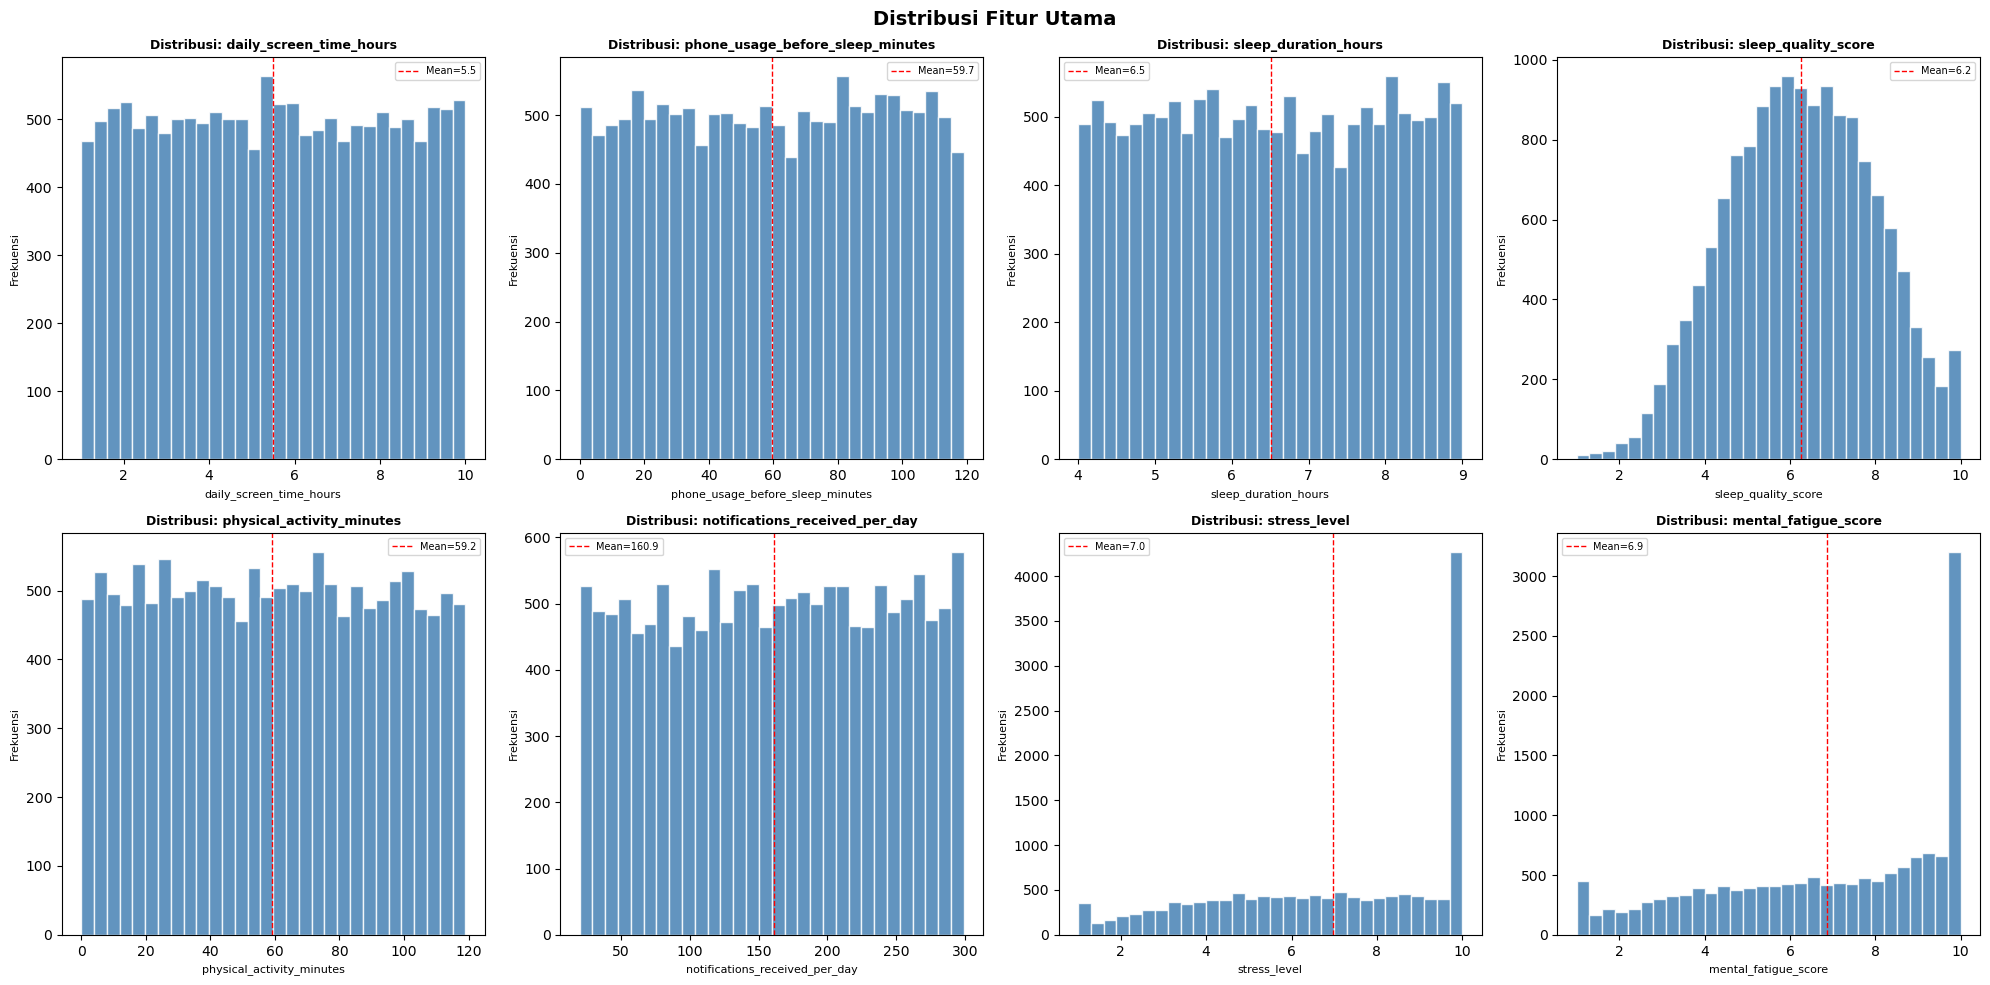

Visualisasi menunjukkan distribusi masing-masing fitur.
Garis merah menandai nilai rata-rata.


In [35]:
# ─── EDA: Distribusi Setiap Fitur Utama ───────────────────────────────────────
available_core = [c for c in CORE_FEATURES if c in df_clean.columns]

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()
for i, col in enumerate(available_core):
    axes[i].hist(df_clean[col], bins=30, color='steelblue', edgecolor='white', alpha=0.85)
    axes[i].set_title(f'Distribusi: {col}', fontsize=9, fontweight='bold')
    axes[i].set_xlabel(col, fontsize=8)
    axes[i].set_ylabel('Frekuensi', fontsize=8)
    mean_val = df_clean[col].mean()
    axes[i].axvline(mean_val, color='red', linestyle='--', linewidth=1, label=f'Mean={mean_val:.1f}')
    axes[i].legend(fontsize=7)

plt.suptitle('Distribusi Fitur Utama', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print("Visualisasi menunjukkan distribusi masing-masing fitur.")
print("Garis merah menandai nilai rata-rata.")

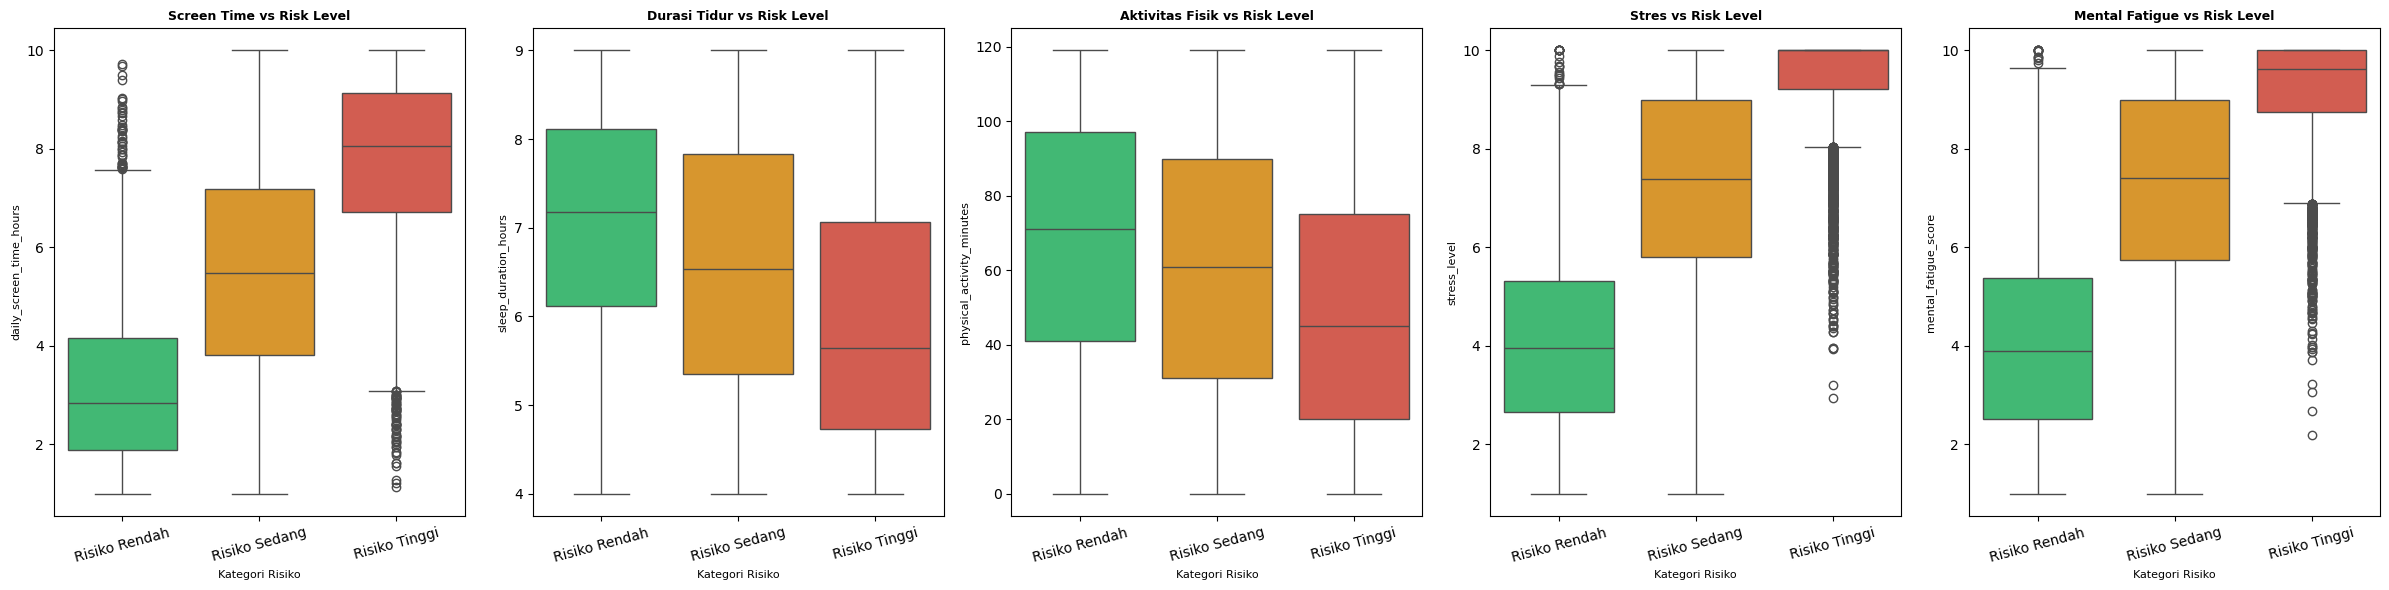

Semakin tinggi risiko, semakin tinggi screen time, stres, dan mental fatigue,
sedangkan durasi tidur dan aktivitas fisik justru semakin rendah.


In [7]:
# ─── EDA: Hubungan Fitur Terhadap Risk Level (Boxplot) ────────────────────────
key_features = [
    ('daily_screen_time_hours', 'Screen Time vs Risk Level'),
    ('sleep_duration_hours', 'Durasi Tidur vs Risk Level'),
    ('physical_activity_minutes', 'Aktivitas Fisik vs Risk Level'),
    ('stress_level', 'Stres vs Risk Level'),
    ('mental_fatigue_score', 'Mental Fatigue vs Risk Level'),
]

risk_order = ['Risiko Rendah', 'Risiko Sedang', 'Risiko Tinggi']
palette = {'Risiko Rendah': '#2ecc71', 'Risiko Sedang': '#f39c12', 'Risiko Tinggi': '#e74c3c'}

fig, axes = plt.subplots(1, 5, figsize=(24, 6))
for ax, (col, title) in zip(axes, key_features):
    if col in df_clean.columns:
        sns.boxplot(data=df_clean, x='risk_level', y=col,
                    order=risk_order, palette=palette, ax=ax)
        ax.set_title(title, fontsize=9, fontweight='bold')
        ax.set_xlabel('Kategori Risiko', fontsize=8)
        ax.set_ylabel(col, fontsize=8)
        ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()
print("Semakin tinggi risiko, semakin tinggi screen time, stres, dan mental fatigue,")
print("sedangkan durasi tidur dan aktivitas fisik justru semakin rendah.")

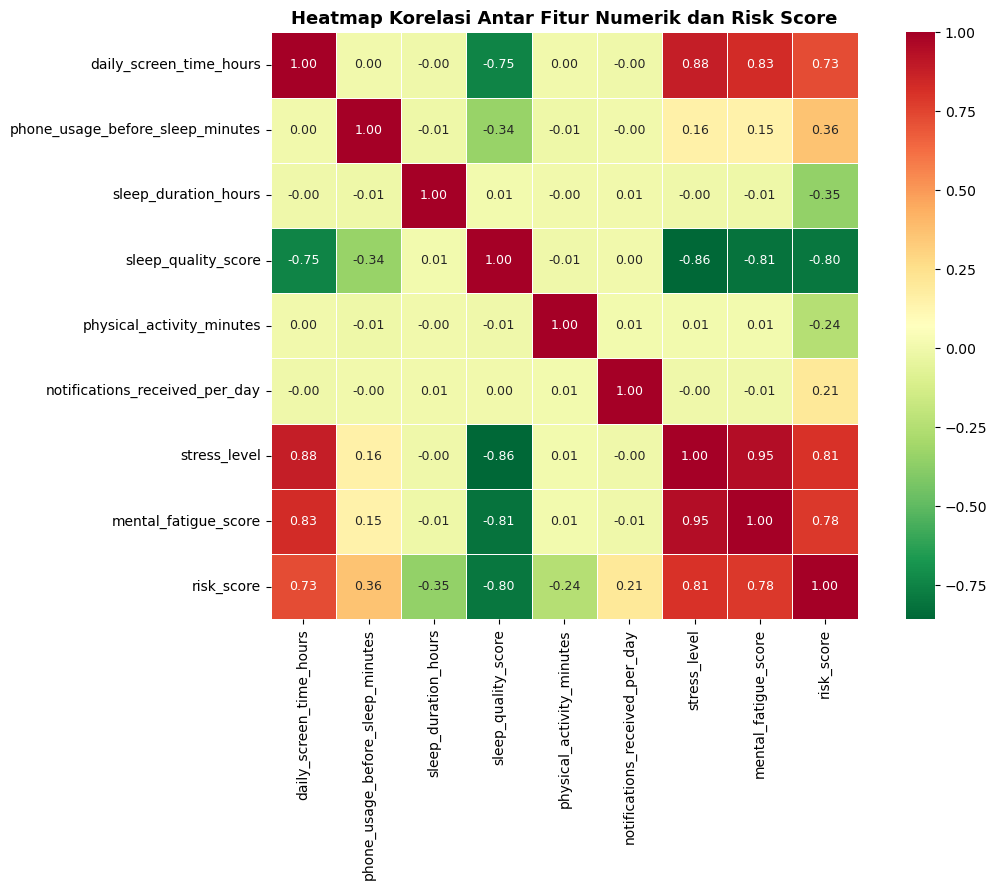

Heatmap menunjukkan korelasi linier antar fitur.
Korelasi positif kuat terhadap risk_score mengindikasikan fitur yang paling berpengaruh.


In [8]:
# ─── EDA: Heatmap Korelasi ────────────────────────────────────────────────────
num_cols = [c for c in available_core if df_clean[c].dtype != 'object'] + ['risk_score']

plt.figure(figsize=(12, 9))
corr_matrix = df_clean[num_cols].corr()

# Heatmap full kotak: mask dihapus agar seluruh matriks korelasi tampil
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn_r',
    linewidths=0.5,
    square=True,
    annot_kws={'size': 9}
)

plt.title('Heatmap Korelasi Antar Fitur Numerik dan Risk Score', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("Heatmap menunjukkan korelasi linier antar fitur.")
print("Korelasi positif kuat terhadap risk_score mengindikasikan fitur yang paling berpengaruh.")


---
## Tahap 7 — Preprocessing Data

Preprocessing adalah langkah transformasi data mentah menjadi format yang siap digunakan untuk melatih model machine learning. Tahapan ini meliputi:
1. Pemilihan fitur input (`X`) dan target (`y`)
2. Encoding target label (`risk_level`) ke integer untuk 3 kelas risiko
3. Pembagian data menjadi data latih dan data uji (80:20, stratified)
4. Normalisasi fitur dengan Min-Max Scaler (`fit_transform` hanya pada data latih, `transform` pada data uji)
5. Cek distribusi kelas pada data latih

Data uji tetap menggunakan distribusi data asli agar evaluasi tidak bias oleh data sintetis.


### 1. Pilih Fitur Utama

In [9]:
# TAHAP 7 — PREPROCESSING DATA

# 1. Pilih Fitur Utama
FEATURES_USED = [c for c in CORE_FEATURES if c in df_clean.columns]

# Tambahkan 'age' jika korelasi signifikan (opsional)
if 'age' in df_clean.columns and df_clean['age'].dtype != 'object':
    corr_age = abs(df_clean['age'].corr(df_clean['risk_score']))
    if corr_age >= 0.05:
        FEATURES_USED.append('age')
        print(f"'age' diikutsertakan (korelasi dengan risk_score: {corr_age:.3f})")
    else:
        print(f"'age' tidak diikutsertakan (korelasi terlalu rendah: {corr_age:.3f})")

print("'gender' TIDAK diikutsertakan sebagai fitur model.")
print(f"\nFitur yang digunakan ({len(FEATURES_USED)} fitur):\n{FEATURES_USED}")



'age' tidak diikutsertakan (korelasi terlalu rendah: 0.003)
'gender' TIDAK diikutsertakan sebagai fitur model.

Fitur yang digunakan (8 fitur):
['daily_screen_time_hours', 'phone_usage_before_sleep_minutes', 'sleep_duration_hours', 'sleep_quality_score', 'physical_activity_minutes', 'notifications_received_per_day', 'stress_level', 'mental_fatigue_score']


### 2. Encode Target (risk_level)

In [10]:
# 2. Encode Target (risk_level)
X = df_clean[FEATURES_USED].values
y_raw = df_clean['risk_level'].values

label_order = ['Risiko Rendah', 'Risiko Sedang', 'Risiko Tinggi']
label_to_int = {label: idx for idx, label in enumerate(label_order)}
int_to_label = {idx: label for label, idx in label_to_int.items()}
y = np.array([label_to_int[lbl] for lbl in y_raw])
print(f"\nEncoding label: {label_to_int}")

# Helper untuk menampilkan distribusi kelas
def print_class_distribution(title, labels, label_map):
    print(f"\n{title}")
    unique, counts = np.unique(labels, return_counts=True)
    total = len(labels)
    for cls_idx, cls_name in label_map.items():
        count = counts[unique.tolist().index(cls_idx)] if cls_idx in unique else 0
        print(f"  {cls_name}: {count} ({count / total * 100:.1f}%)")




Encoding label: {'Risiko Rendah': 0, 'Risiko Sedang': 1, 'Risiko Tinggi': 2}


### 3. Train-Test Split (80:20 stratified)

In [ ]:
# 3. Train-Test Split (80:20 stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)
print(f"\nData latih : {X_train.shape[0]:,} sampel")
print(f"Data uji   : {X_test.shape[0]:,} sampel")



Data latih : 12,000 sampel
Data uji   : 3,000 sampel


### 4. MinMax Scaling (fit pada train, transform pada test)

In [12]:
# 4. MinMax Scaling (fit pada train, transform pada test)
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("\nNormalisasi Min-Max selesai.")
print("  fit_transform: X_train")
print("  transform    : X_test")


Normalisasi Min-Max selesai.
  fit_transform: X_train
  transform    : X_test


### 5. Cek Distribusi Kelas



Distribusi kelas pada data latih (setiap kelas):
  Risiko Rendah: 3640 (30.3%)
  Risiko Sedang: 4522 (37.7%)
  Risiko Tinggi: 3838 (32.0%)


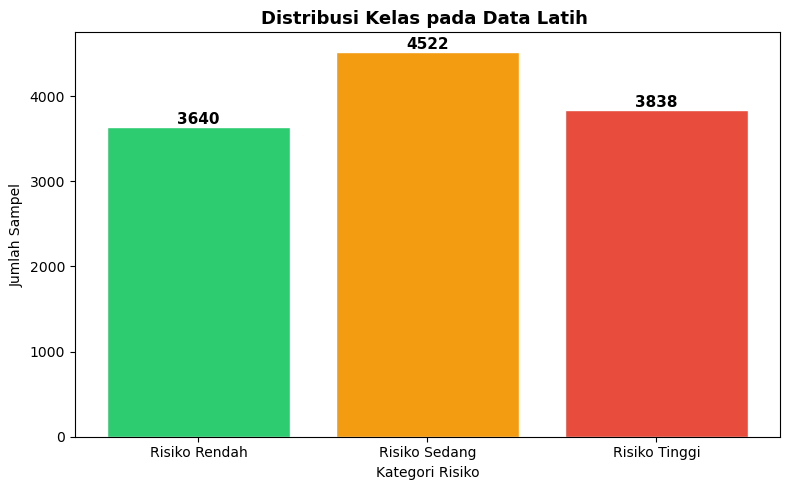

In [13]:
# 5. Cek Distribusi Kelas ()
print_class_distribution("Distribusi kelas pada data latih (setiap kelas):", y_train, int_to_label)

# Visualisasi distribusi kelas
unique_train, counts_train = np.unique(y_train, return_counts=True)
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar([int_to_label[i] for i in unique_train], counts_train,
              color=['#2ecc71', '#f39c12', '#e74c3c'], edgecolor='white')
for bar, val in zip(bars, counts_train):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            str(val), ha='center', fontsize=11, fontweight='bold')
ax.set_title('Distribusi Kelas pada Data Latih ', fontweight='bold', fontsize=13)
ax.set_xlabel('Kategori Risiko'); ax.set_ylabel('Jumlah Sampel')
plt.tight_layout()
plt.show()



---
## Tahap 8 — Hyperparameter Tuning dengan RandomizedSearchCV

Pada tahap ini, **empat model machine learning** di-tune menggunakan **RandomizedSearchCV** dengan **5-fold cross-validation** pada data latih (). Tujuannya adalah menemukan kombinasi hyperparameter terbaik untuk setiap model.

| No | Model | Jenis | Keterangan |
|---|---|---|---|
| 1 | **Logistic Regression** | Linear | Model baseline, sederhana dan mudah diinterpretasikan |
| 2 | **Random Forest** | Ensemble (Bagging) | Robust terhadap overfitting, mendukung feature importance |
| 3 | **XGBoost** | Ensemble (Boosting) | Performa tinggi pada data tabular |
| 4 | **SVM** | Kernel-based | Kemampuan baik membentuk batas keputusan non-linear |

**Konfigurasi Tuning:**
- **Metode**: RandomizedSearchCV (lebih efisien dibanding GridSearchCV)
- **Cross-Validation**: 5 fold, stratified
- **Scoring**: **Recall Risiko Tinggi** (prioritas utama — memilih parameter yang memaksimalkan recall kelas Risiko Tinggi saat CV)
- **n_iter**: Jumlah kombinasi yang diuji secara random per model

**Evaluasi yang fair dan konsisten:**
- Semua model di-tune pada data yang sama (`X_train_scaled`, `y_train`)
- Semua model dievaluasi pada data uji yang sama (`X_test_scaled`, `y_test`)
- Data uji **TIDAK** pernah disentuh saat tuning

**Kriteria pemilihan model terbaik:**
1. **Recall Risiko Tinggi** — prioritas utama *(false negative pada kelas Risiko Tinggi sangat berbahaya)*
2. **F1-Score** — keseimbangan precision dan recall
3. **Accuracy** — akurasi keseluruhan

In [15]:
# TAHAP 8 — HYPERPARAMETER TUNING (RandomizedSearchCV, cv=5)

results = {}
trained_models = {}
predictions = {}
best_params_all = {}  # Menyimpan best params setiap model
cv_results_all = {}   # Menyimpan CV results

target_names = ['Risiko Rendah', 'Risiko Sedang', 'Risiko Tinggi']

# Scoring metric: Recall kelas Risiko Tinggi (prioritas utama)
def recall_tinggi_score(y_true, y_pred):
    return recall_score(y_true, y_pred, average=None)[label_to_int['Risiko Tinggi']]

scoring = make_scorer(recall_tinggi_score)
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("=" * 70)
print("  HYPERPARAMETER TUNING — RandomizedSearchCV (cv=5)")
print("  Scoring: Recall Risiko Tinggi (prioritas)")
print("=" * 70)

# 1. LOGISTIC REGRESSION
print("\n[1/4] Tuning Logistic Regression...")
lr_param_dist = {
    'C': loguniform(1e-3, 1e2),           # Regularization strength
    'penalty': ['l1', 'l2'],               # Regularization type
    'solver': ['saga'],                     # Solver yang support l1 & l2
    'max_iter': [500, 1000, 2000],          # Max iterations
    'class_weight': [None, 'balanced'],     # Class weight
}

lr_search = RandomizedSearchCV(
    LogisticRegression(random_state=42, multi_class='multinomial'),
    param_distributions=lr_param_dist,
    n_iter=30,
    cv=cv_strategy,
    scoring=scoring,
    random_state=42,
    n_jobs=-1,
    verbose=1
)
t0 = time.time()
lr_search.fit(X_train_scaled, y_train)
lr_time = time.time() - t0

lr_best = lr_search.best_estimator_
y_pred_lr = lr_best.predict(X_test_scaled)

results['Logistic Regression'] = {
    'Accuracy' : accuracy_score(y_test, y_pred_lr),
    'Precision': precision_score(y_test, y_pred_lr, average='weighted'),
    'Recall'   : recall_score(y_test, y_pred_lr, average='weighted'),
    'F1-Score' : f1_score(y_test, y_pred_lr, average='weighted'),
    'Recall Risiko Tinggi': recall_score(y_test, y_pred_lr, average=None)[label_to_int['Risiko Tinggi']],
}
trained_models['Logistic Regression'] = lr_best
predictions['Logistic Regression'] = y_pred_lr
best_params_all['Logistic Regression'] = lr_search.best_params_
cv_results_all['Logistic Regression'] = {
    'best_cv_score': lr_search.best_score_,
    'training_time_sec': round(lr_time, 2)
}

print(f"  ✓ Selesai ({lr_time:.1f}s) | Best CV Score: {lr_search.best_score_:.4f}")
print(f"  Best params: {lr_search.best_params_}")

# 2. RANDOM FOREST
print("\n[2/4] Tuning Random Forest...")
rf_param_dist = {
    'n_estimators': randint(50, 500),        # Jumlah trees
    'max_depth': [None, 5, 10, 15, 20, 30],  # Kedalaman maksimum
    'min_samples_split': randint(2, 20),      # Min samples untuk split
    'min_samples_leaf': randint(1, 10),        # Min samples di leaf
    'max_features': ['sqrt', 'log2', None],   # Jumlah fitur per split
    'class_weight': [None, 'balanced', 'balanced_subsample'],
}

rf_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_distributions=rf_param_dist,
    n_iter=50,
    cv=cv_strategy,
    scoring=scoring,
    random_state=42,
    n_jobs=-1,
    verbose=1
)
t0 = time.time()
rf_search.fit(X_train_scaled, y_train)
rf_time = time.time() - t0

rf_best = rf_search.best_estimator_
y_pred_rf = rf_best.predict(X_test_scaled)

results['Random Forest'] = {
    'Accuracy' : accuracy_score(y_test, y_pred_rf),
    'Precision': precision_score(y_test, y_pred_rf, average='weighted'),
    'Recall'   : recall_score(y_test, y_pred_rf, average='weighted'),
    'F1-Score' : f1_score(y_test, y_pred_rf, average='weighted'),
    'Recall Risiko Tinggi': recall_score(y_test, y_pred_rf, average=None)[label_to_int['Risiko Tinggi']],
}
trained_models['Random Forest'] = rf_best
predictions['Random Forest'] = y_pred_rf
best_params_all['Random Forest'] = rf_search.best_params_
cv_results_all['Random Forest'] = {
    'best_cv_score': rf_search.best_score_,
    'training_time_sec': round(rf_time, 2)
}

print(f"  ✓ Selesai ({rf_time:.1f}s) | Best CV Score: {rf_search.best_score_:.4f}")
print(f"  Best params: {rf_search.best_params_}")

# 3. XGBOOST
print("\n[3/4] Tuning XGBoost...")
xgb_param_dist = {
    'n_estimators': randint(50, 500),         # Jumlah boosting rounds
    'max_depth': randint(3, 15),              # Kedalaman tree
    'learning_rate': loguniform(1e-3, 0.3),   # Learning rate
    'subsample': uniform(0.6, 0.4),           # Sample ratio per tree
    'colsample_bytree': uniform(0.6, 0.4),    # Feature ratio per tree
    'min_child_weight': randint(1, 10),        # Min sum of instance weight
    'gamma': uniform(0, 5),                    # Min loss reduction
    'reg_alpha': loguniform(1e-4, 1e1),        # L1 regularization
    'reg_lambda': loguniform(1e-4, 1e1),       # L2 regularization
}

xgb_search = RandomizedSearchCV(
    XGBClassifier(
        random_state=42, eval_metric='mlogloss', n_jobs=-1
    ),
    param_distributions=xgb_param_dist,
    n_iter=50,
    cv=cv_strategy,
    scoring=scoring,
    random_state=42,
    n_jobs=-1,
    verbose=1
)
t0 = time.time()
xgb_search.fit(X_train_scaled, y_train)
xgb_time = time.time() - t0

xgb_best = xgb_search.best_estimator_
y_pred_xgb = xgb_best.predict(X_test_scaled)

results['XGBoost'] = {
    'Accuracy' : accuracy_score(y_test, y_pred_xgb),
    'Precision': precision_score(y_test, y_pred_xgb, average='weighted'),
    'Recall'   : recall_score(y_test, y_pred_xgb, average='weighted'),
    'F1-Score' : f1_score(y_test, y_pred_xgb, average='weighted'),
    'Recall Risiko Tinggi': recall_score(y_test, y_pred_xgb, average=None)[label_to_int['Risiko Tinggi']],
}
trained_models['XGBoost'] = xgb_best
predictions['XGBoost'] = y_pred_xgb
best_params_all['XGBoost'] = xgb_search.best_params_
cv_results_all['XGBoost'] = {
    'best_cv_score': xgb_search.best_score_,
    'training_time_sec': round(xgb_time, 2)
}

print(f"  ✓ Selesai ({xgb_time:.1f}s) | Best CV Score: {xgb_search.best_score_:.4f}")
print(f"  Best params: {xgb_search.best_params_}")

# 4. SVM
print("\n[4/4] Tuning SVM...")
svm_param_dist = {
    'C': loguniform(1e-2, 1e2),              # Regularization
    'kernel': ['rbf', 'poly'],                # Kernel type
    'gamma': loguniform(1e-4, 1e1),           # Kernel coefficient (continuous)
    'degree': [2, 3],                          # Degree (for poly kernel)
    'class_weight': [None, 'balanced'],        # Class weight
}

svm_search = RandomizedSearchCV(
    SVC(probability=True, random_state=42),
    param_distributions=svm_param_dist,
    n_iter=20,
    cv=cv_strategy,
    scoring=scoring,
    random_state=42,
    n_jobs=-1,
    verbose=1
)
t0 = time.time()
svm_search.fit(X_train_scaled, y_train)
svm_time = time.time() - t0

svm_best = svm_search.best_estimator_
y_pred_svm = svm_best.predict(X_test_scaled)

results['SVM'] = {
    'Accuracy' : accuracy_score(y_test, y_pred_svm),
    'Precision': precision_score(y_test, y_pred_svm, average='weighted'),
    'Recall'   : recall_score(y_test, y_pred_svm, average='weighted'),
    'F1-Score' : f1_score(y_test, y_pred_svm, average='weighted'),
    'Recall Risiko Tinggi': recall_score(y_test, y_pred_svm, average=None)[label_to_int['Risiko Tinggi']],
}
trained_models['SVM'] = svm_best
predictions['SVM'] = y_pred_svm
best_params_all['SVM'] = svm_search.best_params_
cv_results_all['SVM'] = {
    'best_cv_score': svm_search.best_score_,
    'training_time_sec': round(svm_time, 2)
}

print(f"  ✓ Selesai ({svm_time:.1f}s) | Best CV Score: {svm_search.best_score_:.4f}")
print(f"  Best params: {svm_search.best_params_}")

# ══════════════════════════════════════════════════════════════════════════════
# RINGKASAN HASIL TUNING
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 70)
print("  RINGKASAN BEST CV SCORE (Recall Risiko Tinggi) SETIAP MODEL")
print("=" * 70)
for name in results:
    cv_info = cv_results_all[name]
    print(f"  {name:25s} | CV Score: {cv_info['best_cv_score']:.4f} | Time: {cv_info['training_time_sec']:.1f}s")


  HYPERPARAMETER TUNING — RandomizedSearchCV (cv=5)
  Scoring: Recall Risiko Tinggi (prioritas)

[1/4] Tuning Logistic Regression...
Fitting 5 folds for each of 30 candidates, totalling 150 fits
  ✓ Selesai (5.6s) | Best CV Score: 0.9682
  Best params: {'C': 0.0016832027985721903, 'class_weight': 'balanced', 'max_iter': 500, 'penalty': 'l2', 'solver': 'saga'}

[2/4] Tuning Random Forest...
Fitting 5 folds for each of 50 candidates, totalling 250 fits
  ✓ Selesai (192.2s) | Best CV Score: 0.9078
  Best params: {'class_weight': 'balanced', 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 353}

[3/4] Tuning XGBoost...
Fitting 5 folds for each of 50 candidates, totalling 250 fits
  ✓ Selesai (73.7s) | Best CV Score: 0.9281
  Best params: {'colsample_bytree': 0.6923575302488596, 'gamma': 1.2051273301300585, 'learning_rate': 0.04926364988526881, 'max_depth': 14, 'min_child_weight': 8, 'n_estimators': 480, 'reg_alpha': 0.000735907565201

In [16]:
# ═══════════════════════════════════════════════════════════════════════════════
# TAMPILKAN BEST HYPERPARAMETERS SETIAP MODEL
# ═══════════════════════════════════════════════════════════════════════════════

print("=" * 70)
print("  BEST HYPERPARAMETERS SETIAP MODEL")
print("=" * 70)

for model_name, params in best_params_all.items():
    print(f"\n── {model_name} ──")
    for param, value in sorted(params.items()):
        if isinstance(value, float):
            print(f"   {param:25s} : {value:.6f}")
        else:
            print(f"   {param:25s} : {value}")

print("\n" + "=" * 70)

  BEST HYPERPARAMETERS SETIAP MODEL

── Logistic Regression ──
   C                         : 0.001683
   class_weight              : balanced
   max_iter                  : 500
   penalty                   : l2
   solver                    : saga

── Random Forest ──
   class_weight              : balanced
   max_depth                 : None
   max_features              : sqrt
   min_samples_leaf          : 2
   min_samples_split         : 2
   n_estimators              : 353

── XGBoost ──
   colsample_bytree          : 0.692358
   gamma                     : 1.205127
   learning_rate             : 0.049264
   max_depth                 : 14
   min_child_weight          : 8
   n_estimators              : 480
   reg_alpha                 : 0.000736
   reg_lambda                : 0.009022
   subsample                 : 0.672894

── SVM ──
   C                         : 0.633865
   class_weight              : balanced
   degree                    : 3
   gamma                     : 5.1405

---
## Tahap 9 — Evaluasi Model pada Test Set

Setelah hyperparameter tuning selesai, model terbaik dari masing-masing algoritma dievaluasi pada **data uji (test set)** yang belum pernah dilihat saat training maupun tuning.

**Metrik evaluasi:**
- Accuracy, Precision, Recall, F1-Score (weighted)
- Recall Risiko Tinggi (metrik kritis)

**Pemilihan model final:**
1. Recall Risiko Tinggi (prioritas utama)
2. F1-Score
3. Accuracy

In [ ]:
# TAHAP 9 — EVALUASI MODEL PADA TEST SET

# TABEL PERBANDINGAN 4 MODEL
df_results = pd.DataFrame(results).T.round(4)
print("\n" + "=" * 70)
print("  PERBANDINGAN PERFORMA 4 MODEL (SETELAH TUNING) — TEST SET")
print("=" * 70)
# AUTO-SELECT MODEL TERBAIK
# Prioritas: (1) Recall Risiko Tinggi → (2) F1-Score → (3) Accuracy
candidate_names = list(results.keys())
BEST_MODEL_NAME = max(candidate_names, key=lambda n: (
    results[n]['Recall Risiko Tinggi'],
    results[n]['F1-Score'],
    results[n]['Accuracy']
))
best_model = trained_models[BEST_MODEL_NAME]

print(f"\n{'=' * 70}")
print(f"  MODEL TERBAIK TERPILIH: {BEST_MODEL_NAME}")
print(f"{'=' * 70}")
print(f"  Accuracy            : {results[BEST_MODEL_NAME]['Accuracy']:.4f}")
print(f"  Precision           : {results[BEST_MODEL_NAME]['Precision']:.4f}")
print(f"  Recall              : {results[BEST_MODEL_NAME]['Recall']:.4f}")
print(f"  F1-Score            : {results[BEST_MODEL_NAME]['F1-Score']:.4f}")
print(f"  Recall Risiko Tinggi: {results[BEST_MODEL_NAME]['Recall Risiko Tinggi']:.4f}")
print(f"  Best CV Score       : {cv_results_all[BEST_MODEL_NAME]['best_cv_score']:.4f}")
print(f"{'=' * 70}")
print(f"\nBest Hyperparameters:")
for param, value in sorted(best_params_all[BEST_MODEL_NAME].items()):
    if isinstance(value, float):
        print(f"  {param:25s} : {value:.6f}")
    else:
        print(f"  {param:25s} : {value}")
print(f"\nAlasan pemilihan:")
print(f"  → {BEST_MODEL_NAME} memiliki Recall Risiko Tinggi tertinggi.")
print(f"  → Recall Risiko Tinggi dijadikan prioritas utama karena")
print(f"    false negative (pengguna berisiko tinggi diprediksi")
print(f"    rendah/sedang) sangat berbahaya bagi pengguna.")


  PERBANDINGAN PERFORMA 4 MODEL (SETELAH TUNING) — TEST SET

  MODEL TERBAIK TERPILIH: Logistic Regression
  Accuracy            : 0.7597
  Precision           : 0.7807
  Recall              : 0.7597
  F1-Score            : 0.7366
  Recall Risiko Tinggi: 0.9698
  Best CV Score       : 0.9682

Best Hyperparameters:
  C                         : 0.001683
  class_weight              : balanced
  max_iter                  : 500
  penalty                   : l2
  solver                    : saga

Alasan pemilihan:
  → Logistic Regression memiliki Recall Risiko Tinggi tertinggi.
  → Recall Risiko Tinggi dijadikan prioritas utama karena
    false negative (pengguna berisiko tinggi diprediksi
    rendah/sedang) sangat berbahaya bagi pengguna.


---
## Tahap 10 — Visualisasi Perbandingan & Detail Model Terpilih

Pada tahap ini ditampilkan:
1. **Bar chart** perbandingan semua metrik antar-model
2. **Confusion matrix** model terpilih
3. **Classification report** lengkap model terpilih
4. **AUC-ROC** model terpilih

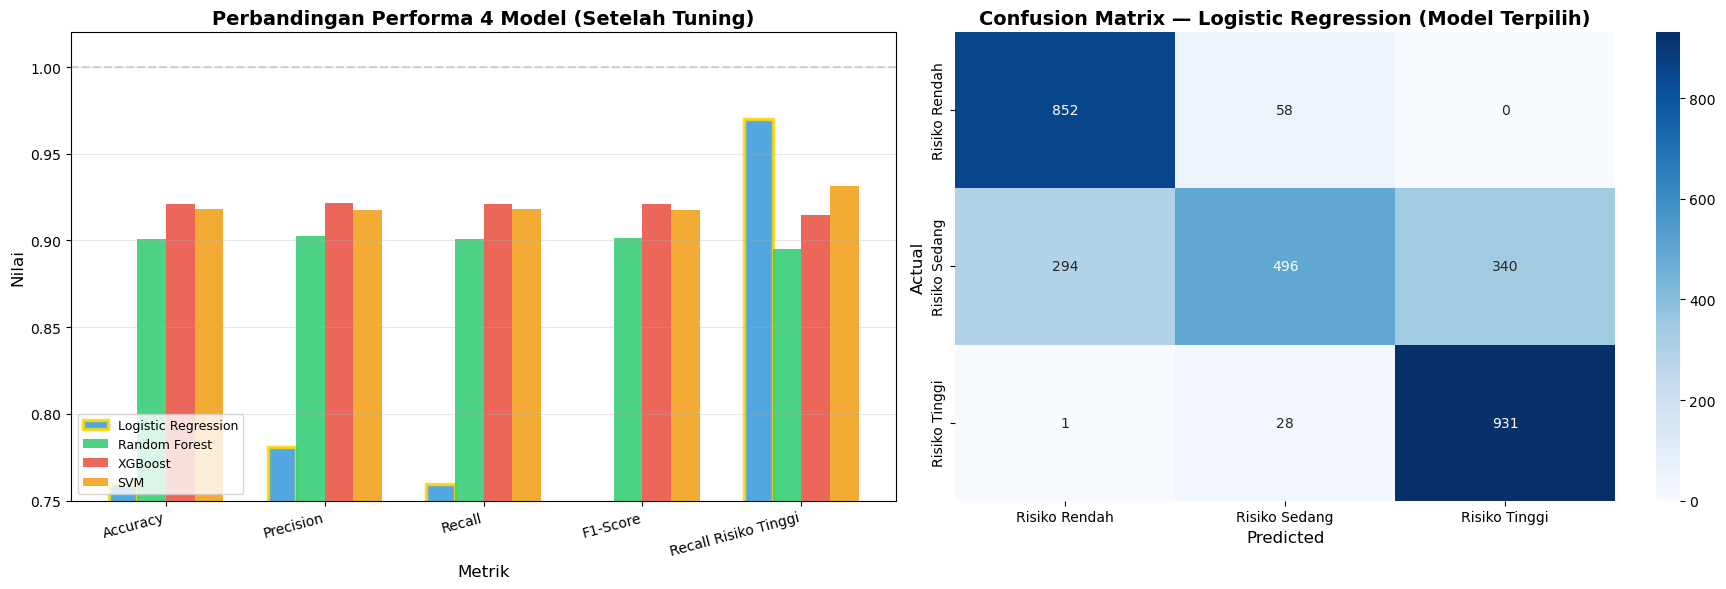

In [19]:
# ─── Visualisasi Perbandingan Model ───────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# 1. Bar Chart Perbandingan Semua Metrik
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'Recall Risiko Tinggi']
x = np.arange(len(metrics_to_plot))
width = 0.18
model_names = list(results.keys())
colors = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12']

for i, name in enumerate(model_names):
    values = [results[name][m] for m in metrics_to_plot]
    bars = axes[0].bar(x + i * width, values, width, label=name, color=colors[i], alpha=0.85)
    # Highlight model terpilih
    if name == BEST_MODEL_NAME:
        for bar in bars:
            bar.set_edgecolor('gold')
            bar.set_linewidth(2.5)

axes[0].set_xlabel('Metrik', fontsize=12)
axes[0].set_ylabel('Nilai', fontsize=12)
axes[0].set_title('Perbandingan Performa 4 Model (Setelah Tuning)', fontsize=14, fontweight='bold')
axes[0].set_xticks(x + width * 1.5)
axes[0].set_xticklabels(metrics_to_plot, rotation=15, ha='right')
axes[0].legend(fontsize=9, loc='lower left')
axes[0].set_ylim(0.75, 1.02)
axes[0].axhline(y=1.0, color='gray', linestyle='--', alpha=0.3)
axes[0].grid(axis='y', alpha=0.3)

# 2. Confusion Matrix Model Terpilih
y_pred_best = predictions[BEST_MODEL_NAME]
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names, ax=axes[1])
axes[1].set_xlabel('Predicted', fontsize=12)
axes[1].set_ylabel('Actual', fontsize=12)
axes[1].set_title(f'Confusion Matrix — {BEST_MODEL_NAME} (Model Terpilih)',
                   fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

In [20]:
# ─── Classification Report & AUC-ROC Model Terpilih ──────────────────────────

y_pred_best = predictions[BEST_MODEL_NAME]

print("=" * 65)
print(f"  CLASSIFICATION REPORT — {BEST_MODEL_NAME}")
print("=" * 65)
print(classification_report(y_test, y_pred_best, target_names=target_names))

# AUC-ROC (One-vs-Rest, Multi-kelas)
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])

if hasattr(best_model, 'predict_proba'):
    y_score_best = best_model.predict_proba(X_test_scaled)
    auc_ovr = roc_auc_score(y_test_bin, y_score_best, multi_class='ovr', average='weighted')
    print(f"AUC-ROC (weighted, One-vs-Rest): {auc_ovr:.4f}")

    # AUC per kelas
    for i, name in enumerate(target_names):
        auc_i = roc_auc_score(y_test_bin[:, i], y_score_best[:, i])
        print(f"  AUC {name}: {auc_i:.4f}")
else:
    print("Model tidak mendukung predict_proba, AUC-ROC tidak dihitung.")

# Tampilkan Confusion Matrix per kelas
print(f"\nDetail Confusion Matrix ({BEST_MODEL_NAME}):")
cm = confusion_matrix(y_test, y_pred_best)
for i, name in enumerate(target_names):
    tp = cm[i, i]
    fn = cm[i, :].sum() - tp
    fp = cm[:, i].sum() - tp
    tn = cm.sum() - tp - fn - fp
    print(f"  {name}: TP={tp}, FP={fp}, FN={fn}, TN={tn}")

  CLASSIFICATION REPORT — Logistic Regression
               precision    recall  f1-score   support

Risiko Rendah       0.74      0.94      0.83       910
Risiko Sedang       0.85      0.44      0.58      1130
Risiko Tinggi       0.73      0.97      0.83       960

     accuracy                           0.76      3000
    macro avg       0.78      0.78      0.75      3000
 weighted avg       0.78      0.76      0.74      3000

AUC-ROC (weighted, One-vs-Rest): 0.9368
  AUC Risiko Rendah: 0.9694
  AUC Risiko Sedang: 0.8779
  AUC Risiko Tinggi: 0.9751

Detail Confusion Matrix (Logistic Regression):
  Risiko Rendah: TP=852, FP=295, FN=58, TN=1795
  Risiko Sedang: TP=496, FP=86, FN=634, TN=1784
  Risiko Tinggi: TP=931, FP=340, FN=29, TN=1700


---
## Tahap 11 — ROC Curve Model Terpilih

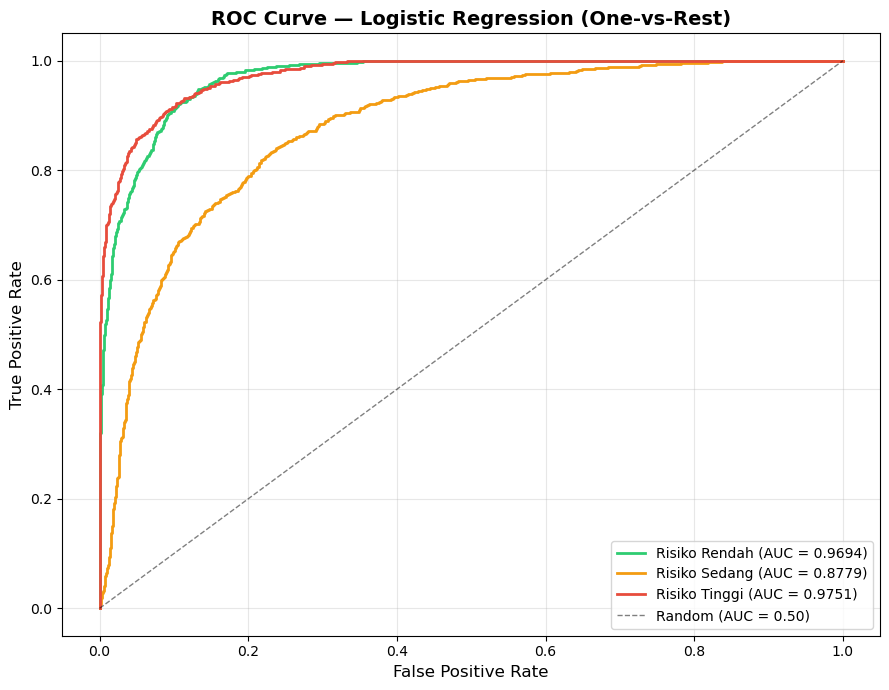

In [21]:
# ─── ROC Curve Model Terpilih ─────────────────────────────────────────────────
from sklearn.metrics import roc_curve, auc

if hasattr(best_model, 'predict_proba'):
    y_score_best = best_model.predict_proba(X_test_scaled)
    y_test_bin = label_binarize(y_test, classes=[0, 1, 2])

    fig, ax = plt.subplots(figsize=(9, 7))
    colors_roc = ['#2ecc71', '#f39c12', '#e74c3c']

    for i, (name, color) in enumerate(zip(target_names, colors_roc)):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score_best[:, i])
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC = {roc_auc:.4f})')

    ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5, label='Random (AUC = 0.50)')
    ax.set_xlabel('False Positive Rate', fontsize=12)
    ax.set_ylabel('True Positive Rate', fontsize=12)
    ax.set_title(f'ROC Curve — {BEST_MODEL_NAME} (One-vs-Rest)', fontsize=14, fontweight='bold')
    ax.legend(loc='lower right', fontsize=10)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig('roc_curve_best.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("Model tidak mendukung predict_proba, ROC Curve tidak ditampilkan.")

---
## Tahap 12 — Interpretasi Fitur (Permutation Importance)

**Permutation Importance** digunakan untuk mengukur kontribusi setiap fitur terhadap performa model terpilih. Metode ini bekerja dengan mengacak satu fitur secara bergantian dan mengukur seberapa besar penurunan performa model akibat pengacakan tersebut.

Fitur dengan importance tinggi menunjukkan bahwa fitur tersebut sangat berpengaruh terhadap prediksi risiko kesehatan.

Permutation Importance (Logistic Regression):


,Fitur,Importance,Std Dev
2,sleep_duration_hours,0.0611,0.0045
4,physical_activity_minutes,0.0340,0.0037
1,phone_usage_before_sleep_minutes,0.0313,0.0044
6,stress_level,0.0296,0.0056
5,notifications_received_per_day,0.0216,0.0039
7,mental_fatigue_score,0.0192,0.0057
0,daily_screen_time_hours,0.0174,0.0062
3,sleep_quality_score,-0.0109,0.0043


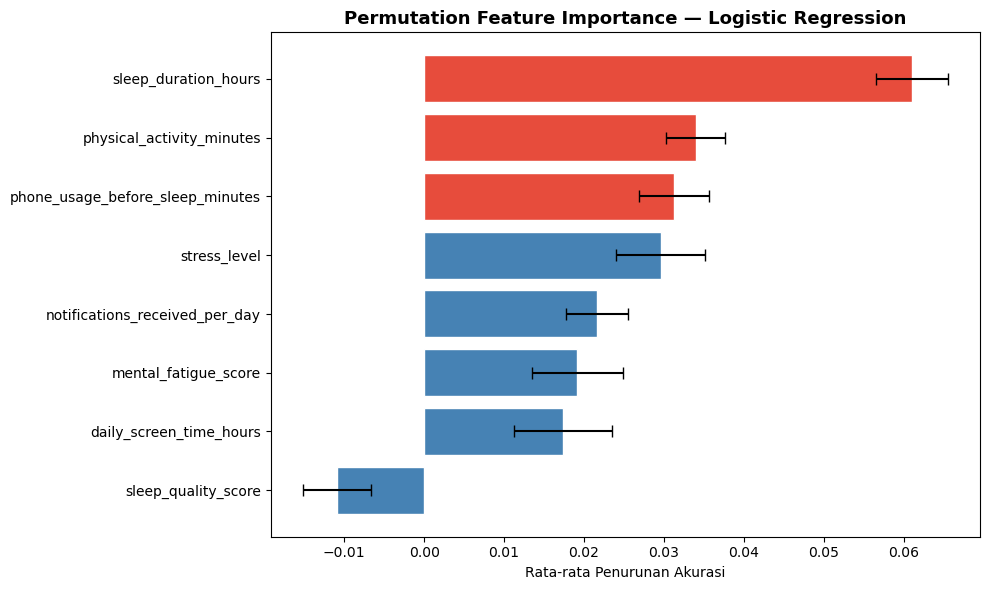


Tiga fitur paling berpengaruh: ['sleep_duration_hours', 'physical_activity_minutes', 'phone_usage_before_sleep_minutes']
Fitur dengan importance tinggi adalah fitur yang paling perlu diperhatikan
dalam upaya pencegahan risiko kesehatan.


In [22]:
# ─── Permutation Importance (menggunakan model terpilih) ─────────────────────
perm_imp = permutation_importance(
    best_model, X_test_scaled, y_test,
    n_repeats=20, random_state=42, n_jobs=-1
)

feat_imp_df = pd.DataFrame({
    'Fitur'        : FEATURES_USED,
    'Importance'   : perm_imp.importances_mean,
    'Std Dev'      : perm_imp.importances_std
}).sort_values('Importance', ascending=False)

print(f"Permutation Importance ({BEST_MODEL_NAME}):")
display(feat_imp_df.round(4))

# Visualisasi
plt.figure(figsize=(10, 6))
colors_bar = ['#e74c3c' if i < 3 else 'steelblue' for i in range(len(feat_imp_df))]
plt.barh(feat_imp_df['Fitur'][::-1],
         feat_imp_df['Importance'][::-1],
         xerr=feat_imp_df['Std Dev'][::-1],
         color=colors_bar[::-1], edgecolor='white', capsize=4)
plt.title(f'Permutation Feature Importance — {BEST_MODEL_NAME}',
          fontweight='bold', fontsize=13)
plt.xlabel('Rata-rata Penurunan Akurasi')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

top3 = feat_imp_df['Fitur'].head(3).tolist()
print(f"\nTiga fitur paling berpengaruh: {top3}")
print("Fitur dengan importance tinggi adalah fitur yang paling perlu diperhatikan")
print("dalam upaya pencegahan risiko kesehatan.")

---
## Tahap 13 — Simpan Model Final & Artefak Deployment

Pada tahap ini, model terbaik yang telah terpilih disimpan bersama seluruh artefak pendukung yang diperlukan untuk deployment web:

| Artefak | Format | Keterangan |
|---|---|---|
| Model final | `.joblib` | Model terpilih (LR/RF/SVM) atau XGBoost |
| Model XGBoost (opsional) | `.json` | Format native XGBoost (jika terpilih) |
| Scaler | `.pkl` | MinMaxScaler untuk normalisasi input |
| Feature config | `.json` | Urutan fitur yang digunakan saat training |
| Label mapping | `.json` | Pemetaan kelas (int ↔ string) |
| Scaler config | `.json` | Parameter lengkap MinMaxScaler |
| Model info | `.json` | Metadata model: nama, metrik, fitur, mapping, hyperparameters |

In [23]:
# ─── Simpan Model Final & Artefak Deployment ─────────────────────────────────
import os

os.makedirs('model_final', exist_ok=True)

# ════════════════════════════════════════════════════════════════
# 1. Simpan Model Final (.joblib)
# ════════════════════════════════════════════════════════════════
joblib.dump(best_model, 'model_final/final_health_risk_model.joblib')
print(f"✓ Model final disimpan: model_final/final_health_risk_model.joblib ({BEST_MODEL_NAME})")

# Jika XGBoost terpilih, simpan juga format native .json
if BEST_MODEL_NAME == 'XGBoost':
    best_model.save_model('model_final/final_health_risk_model.json')
    print("✓ XGBoost native disimpan: model_final/final_health_risk_model.json")

# ════════════════════════════════════════════════════════════════
# 2. Simpan Scaler (.pkl)
# ════════════════════════════════════════════════════════════════
joblib.dump(scaler, 'model_final/scaler.pkl')
print("✓ Scaler disimpan: model_final/scaler.pkl")

# ════════════════════════════════════════════════════════════════
# 3. Simpan Feature Order (feature_config.json)
# ════════════════════════════════════════════════════════════════
feature_config = {
    'features': FEATURES_USED,
    'n_features': len(FEATURES_USED),
    'description': 'Urutan fitur yang digunakan saat training model'
}
with open('model_final/feature_config.json', 'w', encoding='utf-8') as f:
    json.dump(feature_config, f, indent=2, ensure_ascii=False)
print("✓ Feature config disimpan: model_final/feature_config.json")

# ════════════════════════════════════════════════════════════════
# 4. Simpan Label Mapping (label_mapping.json)
# ════════════════════════════════════════════════════════════════
label_mapping_export = {
    'int_to_label': {str(k): v for k, v in int_to_label.items()},
    'label_to_int': label_to_int
}
with open('model_final/label_mapping.json', 'w', encoding='utf-8') as f:
    json.dump(label_mapping_export, f, indent=2, ensure_ascii=False)
print("✓ Label mapping disimpan: model_final/label_mapping.json")

# ════════════════════════════════════════════════════════════════
# 5. Simpan Scaler Config (scaler_config.json)
# ════════════════════════════════════════════════════════════════
scaler_config = {
    'features': FEATURES_USED,
    'scale_': scaler.scale_.tolist(),
    'min_': scaler.min_.tolist(),
    'data_min_': scaler.data_min_.tolist(),
    'data_max_': scaler.data_max_.tolist(),
    'data_range_': scaler.data_range_.tolist(),
    'feature_range': list(scaler.feature_range)
}
with open('model_final/scaler_config.json', 'w', encoding='utf-8') as f:
    json.dump(scaler_config, f, indent=2, ensure_ascii=False)
print("✓ Scaler config disimpan: model_final/scaler_config.json")

# ════════════════════════════════════════════════════════════════
# 6. Simpan Model Info (final_model_info.json)
# ════════════════════════════════════════════════════════════════
# Convert best_params values to JSON-serializable types
serializable_best_params = {}
for model_name, params in best_params_all.items():
    serializable_best_params[model_name] = {}
    for k, v in params.items():
        if isinstance(v, (np.integer,)):
            serializable_best_params[model_name][k] = int(v)
        elif isinstance(v, (np.floating,)):
            serializable_best_params[model_name][k] = float(v)
        else:
            serializable_best_params[model_name][k] = v

final_model_info = {
    'model_name': BEST_MODEL_NAME,
    'tuning_method': 'RandomizedSearchCV (cv=5, scoring=f1_weighted)',
    'selection_scope': ['Logistic Regression', 'Random Forest', 'XGBoost', 'SVM'],
    'selection_metric': 'Recall Risiko Tinggi (prioritas), lalu F1-Score, lalu Accuracy',
    'features': FEATURES_USED,
    'int_to_label': {str(k): v for k, v in int_to_label.items()},
    'best_hyperparameters': serializable_best_params,
    'cv_results': {
        k: {mk: round(float(mv), 6) if isinstance(mv, float) else mv for mk, mv in v.items()}
        for k, v in cv_results_all.items()
    },
    'test_metrics': {
        k: {mk: round(float(mv), 6) for mk, mv in v.items()}
        for k, v in results.items()
    }
}
with open('model_final/final_model_info.json', 'w', encoding='utf-8') as f:
    json.dump(final_model_info, f, indent=2, ensure_ascii=False)
print("✓ Model info disimpan: model_final/final_model_info.json")

# ════════════════════════════════════════════════════════════════
# RINGKASAN
# ════════════════════════════════════════════════════════════════
print("\n" + "=" * 65)
print("  RINGKASAN ARTEFAK DEPLOYMENT")
print("=" * 65)
artifacts = [
    ("Model final (.joblib)", f"model_final/final_health_risk_model.joblib"),
    ("Scaler (.pkl)", "model_final/scaler.pkl"),
    ("Feature config (.json)", "model_final/feature_config.json"),
    ("Label mapping (.json)", "model_final/label_mapping.json"),
    ("Scaler config (.json)", "model_final/scaler_config.json"),
    ("Model info (.json)", "model_final/final_model_info.json"),
]
if BEST_MODEL_NAME == 'XGBoost':
    artifacts.insert(1, ("XGBoost native (.json)", "model_final/final_health_risk_model.json"))

for name, path in artifacts:
    size = os.path.getsize(path)
    print(f"  {name:30s} → {path} ({size:,} bytes)")
print("=" * 65)

✓ Model final disimpan: model_final/final_health_risk_model.joblib (Logistic Regression)
✓ Scaler disimpan: model_final/scaler.pkl
✓ Feature config disimpan: model_final/feature_config.json
✓ Label mapping disimpan: model_final/label_mapping.json
✓ Scaler config disimpan: model_final/scaler_config.json
✓ Model info disimpan: model_final/final_model_info.json

  RINGKASAN ARTEFAK DEPLOYMENT
  Model final (.joblib)          → model_final/final_health_risk_model.joblib (1,087 bytes)
  Scaler (.pkl)                  → model_final/scaler.pkl (983 bytes)
  Feature config (.json)         → model_final/feature_config.json (367 bytes)
  Label mapping (.json)          → model_final/label_mapping.json (211 bytes)
  Scaler config (.json)          → model_final/scaler_config.json (1,041 bytes)
  Model info (.json)             → model_final/final_model_info.json (2,800 bytes)


---
## Kesimpulan Akhir

Pada bagian ini dirangkum seluruh hasil penelitian yang dilakukan menggunakan kerangka metodologi **CRISP-DM**, mencakup pemilihan model final dari 4 kandidat (Logistic Regression, Random Forest, XGBoost, SVM) yang telah melalui **hyperparameter tuning** menggunakan **RandomizedSearchCV** serta artefak yang dihasilkan untuk deployment web.

---
## Tahap 14 — Testing Model dengan Data Baru

Cell ini untuk mencoba model yang sudah disimpan pada data baru.
Ganti nilai variabel `new_data` sesuai input yang ingin diuji.


In [25]:
# Tahap 14 — Testing Model dengan Data Baru
import joblib
import json
import numpy as np
import pandas as pd

# 1. Load model dan artefak
model = joblib.load('model_final/final_health_risk_model.joblib')
scaler = joblib.load('model_final/scaler.pkl')

with open('model_final/feature_config.json', 'r') as f:
    feature_config = json.load(f)
features = feature_config['features']

with open('model_final/label_mapping.json', 'r') as f:
    label_mapping = json.load(f)
int_to_label = label_mapping['int_to_label']
label_to_int = label_mapping['label_to_int']

print(f"Model: {type(model).__name__}")
print(f"Fitur ({len(features)}): {features}")
print(f"Label: {int_to_label}")
print()

# 2. Input data baru — GANTI NILAI INI sesuai data yang ingin diuji
# Format: [screen_time, phone_before_sleep, sleep_dur, sleep_quality,
#          physical_activity, notifications, stress_level, mental_fatigue]
# Jika age digunakan sebagai fitur, tambahkan di akhir
new_data = [
    [6.5, 45, 6.2, 7.5, 60, 150, 6.0, 5.0],  # Contoh 1
    [9.0, 80, 4.5, 3.0, 10, 250, 9.0, 8.5],  # Contoh 2 (risiko tinggi)
    [2.0, 15, 8.0, 9.5, 100, 50, 2.0, 2.5],   # Contoh 3 (risiko rendah)
]

df_input = pd.DataFrame(new_data, columns=features)
print("Data Input:")
display(df_input)

# 3. Scaling & Prediksi
X_new = scaler.transform(np.array(new_data))
y_pred = model.predict(X_new)
y_proba = model.predict_proba(X_new)

# 4. Tampilkan hasil
print()
print("=" * 65)
print("  HASIL PREDIKSI")
print("=" * 65)
for i in range(len(new_data)):
    kelas = int_to_label[str(y_pred[i])]
    proba = {int_to_label[str(j)]: round(float(y_proba[i][j]), 4) for j in range(len(y_proba[i]))}
    print(f"\nData ke-{i+1}:")
    print(f"  Prediksi kelas: {kelas}")
    print(f"  Probabilitas: {proba}")
    print(f"  Risk Score Tinggi: {round(float(y_proba[i][label_to_int['Risiko Tinggi']]) * 100, 1)}%")

print("\n" + "=" * 65)


Model: LogisticRegression
Fitur (8): ['daily_screen_time_hours', 'phone_usage_before_sleep_minutes', 'sleep_duration_hours', 'sleep_quality_score', 'physical_activity_minutes', 'notifications_received_per_day', 'stress_level', 'mental_fatigue_score']
Label: {'0': 'Risiko Rendah', '1': 'Risiko Sedang', '2': 'Risiko Tinggi'}

Data Input:


,daily_screen_time_hours,phone_usage_before_sleep_minutes,sleep_duration_hours,sleep_quality_score,physical_activity_minutes,notifications_received_per_day,stress_level,mental_fatigue_score
0,6.5,45,6.2,7.5,60,150,6.0,5.0
1,9.0,80,4.5,3.0,10,250,9.0,8.5
2,2.0,15,8.0,9.5,100,50,2.0,2.5



  HASIL PREDIKSI

Data ke-1:
  Prediksi kelas: Risiko Rendah
  Probabilitas: {'Risiko Rendah': 0.3936, 'Risiko Sedang': 0.3686, 'Risiko Tinggi': 0.2378}
  Risk Score Tinggi: 23.8%

Data ke-2:
  Prediksi kelas: Risiko Tinggi
  Probabilitas: {'Risiko Rendah': 0.0563, 'Risiko Sedang': 0.2406, 'Risiko Tinggi': 0.7031}
  Risk Score Tinggi: 70.3%

Data ke-3:
  Prediksi kelas: Risiko Rendah
  Probabilitas: {'Risiko Rendah': 0.8043, 'Risiko Sedang': 0.1709, 'Risiko Tinggi': 0.0248}
  Risk Score Tinggi: 2.5%



In [ ]:
# ─── Kesimpulan Akhir ─────────────────────────────────────────────────────────
print("=" * 70)
print("              KESIMPULAN AKHIR PROJECT (CRISP-DM)")
print("=" * 70)

print(f"""
METODOLOGI: CRISP-DM (Cross-Industry Standard Process for Data Mining)

1. BUSINESS UNDERSTANDING
   Tujuan: Memprediksi risiko kesehatan berdasarkan pola gaya hidup modern.
   Kategori: Risiko Rendah, Risiko Sedang, Risiko Tinggi.

2. DATA UNDERSTANDING
   Dataset: 'sleep_mobile_stress_dataset_15000.csv' ({df_clean.shape[0]:,} baris)
   Jumlah fitur input: {len(FEATURES_USED)}
   Fitur: {FEATURES_USED}

3. DATA PREPARATION
   - Pembersihan data, deteksi outlier
   - Pembentukan label risiko dengan weighted scoring
   - Train-Test Split (80:20 stratified)
   - Normalisasi Min-Max Scaling (fit pada train, transform pada test)

4. MODELING
   Model yang diuji:
     a) Logistic Regression
     b) Random Forest
     c) XGBoost
     d) SVM

   Hyperparameter Tuning: RandomizedSearchCV (cv=5, scoring=f1_weighted)

   Kriteria pemilihan:
     → Recall Risiko Tinggi (prioritas utama)
     → F1-Score
     → Accuracy

   MODEL FINAL TERPILIH: {BEST_MODEL_NAME}
     Accuracy            : {results[BEST_MODEL_NAME]['Accuracy']:.4f}
     Precision           : {results[BEST_MODEL_NAME]['Precision']:.4f}
     Recall              : {results[BEST_MODEL_NAME]['Recall']:.4f}
     F1-Score            : {results[BEST_MODEL_NAME]['F1-Score']:.4f}
     Recall Risiko Tinggi: {results[BEST_MODEL_NAME]['Recall Risiko Tinggi']:.4f}
     Best CV Score       : {cv_results_all[BEST_MODEL_NAME]['best_cv_score']:.4f}

5. EVALUATION
   Semua model dievaluasi secara fair dan konsisten.
   Metrik: Accuracy, Precision, Recall, F1-Score, Recall Risiko Tinggi.

6. DEPLOYMENT
   Model final : model_final/final_health_risk_model.joblib ({BEST_MODEL_NAME})
   Backend     : FastAPI (main.py)
   Inference   : predict.py
   Artefak     : scaler.pkl, feature_config.json, scaler_config.json,
                  label_mapping.json, final_model_info.json
""")

print("=" * 70)
print("Penelitian selesai menggunakan kerangka CRISP-DM.")
print(f"Model final: {BEST_MODEL_NAME} (model_final/final_health_risk_model.joblib)")
print("=" * 70)

              KESIMPULAN AKHIR PROJECT (CRISP-DM)

METODOLOGI: CRISP-DM (Cross-Industry Standard Process for Data Mining)

1. BUSINESS UNDERSTANDING
   Tujuan: Memprediksi risiko kesehatan berdasarkan pola gaya hidup modern.
   Kategori: Risiko Rendah, Risiko Sedang, Risiko Tinggi.

2. DATA UNDERSTANDING
   Dataset: 'sleep_mobile_stress_dataset_15000.csv' (15,000 baris)
   Jumlah fitur input: 8
   Fitur: ['daily_screen_time_hours', 'phone_usage_before_sleep_minutes', 'sleep_duration_hours', 'sleep_quality_score', 'physical_activity_minutes', 'notifications_received_per_day', 'stress_level', 'mental_fatigue_score']

3. DATA PREPARATION
   - Pembersihan data, deteksi outlier
   - Pembentukan label risiko dengan weighted scoring
   - Train-Test Split (80:20 stratified)
   - Normalisasi Min-Max Scaling (fit pada train, transform pada test)

4. MODELING
   Model yang diuji:
     a) Logistic Regression
     b) Random Forest
     c) XGBoost
     d) SVM

   Hyperparameter Tuning: RandomizedSea